# 0. Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading Clean Dataset:

In [2]:
merged_df = pd.read_csv('V2-merged_df_noOutliers.csv')
merged_df.head(2)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389,-0.538272


# 2. Splitting Data

In [3]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [4]:
# FOR MODEL

X = merged_df.drop(columns = ['Standard Value','pIC50 Value','Smiles','QT-pIC50 Value','cid'])
y = merged_df['pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

# 3. Missing Data Imputation

In [5]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)


# 4. Removing Constants and Dublicated

In [6]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

print(X_train.shape)

(742, 2121)
(742, 1858)
CPU times: user 897 ms, sys: 25.9 ms, total: 923 ms
Wall time: 926 ms


# 5. Outliers

In [7]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

CPU times: user 2 µs, sys: 1e+03 ns, total: 3 µs
Wall time: 4.29 µs


# 6. YeoJohnsonTransformer:

In [8]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs


# 7. Scaling:

In [9]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.48 µs


# 8. Single-Models:

In [10]:
%%time

#del model_1

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping


# Define the improved neural network model
model_1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),  # Batch normalization layer
    Dropout(0.4),  # Reduced dropout rate
    Dense(64, activation='relu'),
    BatchNormalization(),  # Batch normalization layer
    Dropout(0.3),  # Reduced dropout rate
    Dense(32, activation='relu'),
    BatchNormalization(),  # Batch normalization layer
    Dropout(0.2),  # Reduced dropout ra
    Dense(16, activation='relu'),
    BatchNormalization(),  # Batch normalization layer
    Dense(1, activation='linear')  # Linear activation for regression
])


# Compile the model with an optimized optimizer (e.g., Adam) and learning rate
optimizer = Adam(learning_rate=0.0007)  # Increased learning rate
model_1.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['mae']
)

# Apply learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=30,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with adjusted batch size and epochs
history_improved = model_1.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test),
    shuffle=True,
    verbose=1,
    callbacks=[reduce_lr,early_stopping]
)



from sklearn.metrics import r2_score

# Predict on the test set
y_pred = model_1.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 43.4540 - mae: 6.3631 - val_loss: 41.2983 - val_mae: 6.3233 - learning_rate: 7.0000e-04
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41.1690 - mae: 6.2933 - val_loss: 40.7308 - val_mae: 6.2909 - learning_rate: 7.0000e-04
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39.1018 - mae: 6.1379 - val_loss: 37.7158 - val_mae: 6.0597 - learning_rate: 7.0000e-04
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39.5261 - mae: 6.1652 - val_loss: 36.9297 - val_mae: 6.0042 - learning_rate: 7.0000e-04
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.3418 - mae: 5.9982 - val_loss: 34.4538 - val_mae: 5.8017 - learning_rate: 7.0000e-04
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.5923 - mae: 5.8609 - val_loss: 31.5901 - val_mae: 5.5350 - learning_rate: 7.0000e-04
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.0173 - mae: 5.7158 - val_loss: 29.9515 - val_mae: 5.391

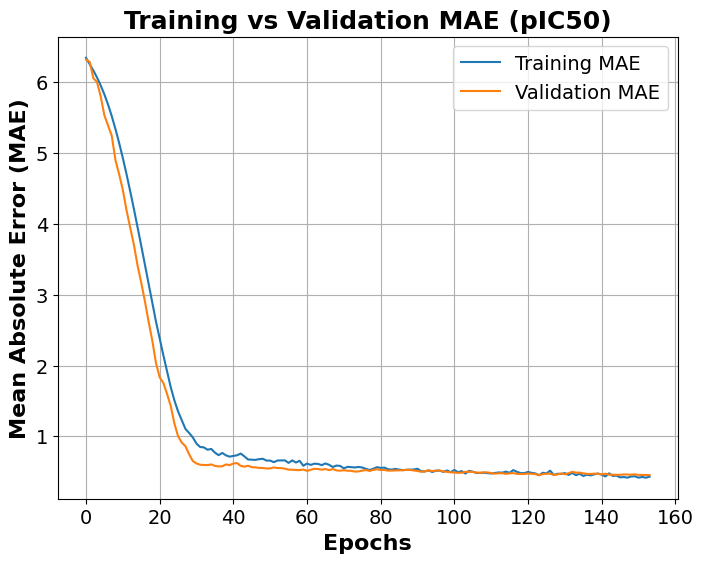

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plotting MAE for training and validation (test) data
plt.plot(history_improved.history['mae'], label='Training MAE')
plt.plot(history_improved.history['val_mae'], label='Validation MAE')

# Adding title, labels, grid, and legend
plt.title('Training vs Validation MAE (pIC50)', fontsize=18, weight='bold')
plt.xlabel('Epochs', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16, weight='bold')
plt.grid(True)
plt.legend(fontsize=14)

# Adjusting tick parameters
plt.tick_params(axis='both', which='major', labelsize=14)

# Display the plot
plt.show()


# 9. Feachures contribition: SHAP

- use .py file (too long for Jupyter)

In [ ]:
import shap
import pandas as pd

# Create an explainer object for your NN model
explainer = shap.KernelExplainer(model_1.predict, X_train)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Calculate the mean absolute SHAP value for each feature
mean_shap_values = np.mean(np.abs(shap_values), axis=0)

# Create a DataFrame to store feature names and their importance coefficients
shap_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame with feature names
    'Importance': mean_shap_values
})

# Sort by importance (optional)
shap_importance_df = shap_importance_df.sort_values(by='Importance', ascending=False)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step


Using 742 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/131 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
